This is an attempt to only use a subset of the UCI heart attack dataset as FHIR does not expose all the data used in their dataset.

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

In [ ]:
dataC = pd.read_csv('processed.cleveland.data')
dataC

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0,1
299,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0,2
300,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0,3
301,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0,1


In [ ]:
dataC['dataset_source'] = 0
dataC

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,dataset_source
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,0
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,0
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0,1,0
299,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0,2,0
300,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0,3,0
301,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0,1,0


In [ ]:
dataH = pd.read_csv('processed.hungarian.data')
dataH

,28,1,2,130,132,0,2.1,185,0.1,0.2,?,?.1,?.2,0.3
0,29,1,2,120,243,0,0,160,0,0.0,?,?,?,0
1,29,1,2,140,?,0,0,170,0,0.0,?,?,?,0
2,30,0,1,170,237,0,1,170,0,0.0,?,?,6,0
3,31,0,2,100,219,0,1,150,0,0.0,?,?,?,0
4,32,0,2,105,198,0,0,165,0,0.0,?,?,?,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
288,52,1,4,160,331,0,0,94,1,2.5,?,?,?,1
289,54,0,3,130,294,0,1,100,1,0.0,2,?,?,1
290,56,1,4,155,342,1,0,150,1,3.0,2,?,?,1
291,58,0,2,180,393,0,0,110,1,1.0,2,?,7,1


In [ ]:
dataH['dataset_source'] = 1
dataH

,28,1,2,130,132,0,2.1,185,0.1,0.2,?,?.1,?.2,0.3,dataset_source
0,29,1,2,120,243,0,0,160,0,0.0,?,?,?,0,1
1,29,1,2,140,?,0,0,170,0,0.0,?,?,?,0,1
2,30,0,1,170,237,0,1,170,0,0.0,?,?,6,0,1
3,31,0,2,100,219,0,1,150,0,0.0,?,?,?,0,1
4,32,0,2,105,198,0,0,165,0,0.0,?,?,?,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
288,52,1,4,160,331,0,0,94,1,2.5,?,?,?,1,1
289,54,0,3,130,294,0,1,100,1,0.0,2,?,?,1,1
290,56,1,4,155,342,1,0,150,1,3.0,2,?,?,1,1
291,58,0,2,180,393,0,0,110,1,1.0,2,?,7,1,1


In [ ]:
dataS = pd.read_csv('processed.switzerland.data')
dataS

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,32,1,1,95,0,?,0,127,0,.7,1,?,?,1
1,34,1,4,115,0,?,?,154,0,.2,1,?,?,1
2,35,1,4,?,0,?,0,130,1,?,?,?,7,3
3,36,1,4,110,0,?,0,125,1,1,2,?,6,1
4,38,0,4,105,0,?,0,166,0,2.8,1,?,?,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118,70,1,4,115,0,0,1,92,1,0,2,?,7,1
119,70,1,4,140,0,1,0,157,1,2,2,?,7,3
120,72,1,3,160,0,?,2,114,0,1.6,2,2,?,0
121,73,0,3,160,0,0,1,121,0,0,1,?,3,1


In [ ]:
dataS['dataset_source'] = 2
dataS

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,dataset_source
0,32,1,1,95,0,?,0,127,0,.7,1,?,?,1,2
1,34,1,4,115,0,?,?,154,0,.2,1,?,?,1,2
2,35,1,4,?,0,?,0,130,1,?,?,?,7,3,2
3,36,1,4,110,0,?,0,125,1,1,2,?,6,1,2
4,38,0,4,105,0,?,0,166,0,2.8,1,?,?,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118,70,1,4,115,0,0,1,92,1,0,2,?,7,1,2
119,70,1,4,140,0,1,0,157,1,2,2,?,7,3,2
120,72,1,3,160,0,?,2,114,0,1.6,2,2,?,0,2
121,73,0,3,160,0,0,1,121,0,0,1,?,3,1,2


In [ ]:
dataVa = pd.read_csv('processed.va.data')
dataVa

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,4,140,260,0,1,112,1,3,2,?,?,2
1,44,1,4,130,209,0,1,127,0,0,?,?,?,0
2,60,1,4,132,218,0,1,140,1,1.5,3,?,?,2
3,55,1,4,142,228,0,1,149,1,2.5,1,?,?,1
4,66,1,3,110,213,1,2,99,1,1.3,2,?,?,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,54,0,4,127,333,1,1,154,0,0,?,?,?,1
196,62,1,1,?,139,0,1,?,?,?,?,?,?,0
197,55,1,4,122,223,1,1,100,0,0,?,?,6,2
198,58,1,4,?,385,1,2,?,?,?,?,?,?,0


In [ ]:
dataVa['dataset_source'] = 3
dataVa

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,dataset_source
0,63,1,4,140,260,0,1,112,1,3,2,?,?,2,3
1,44,1,4,130,209,0,1,127,0,0,?,?,?,0,3
2,60,1,4,132,218,0,1,140,1,1.5,3,?,?,2,3
3,55,1,4,142,228,0,1,149,1,2.5,1,?,?,1,3
4,66,1,3,110,213,1,2,99,1,1.3,2,?,?,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,54,0,4,127,333,1,1,154,0,0,?,?,?,1,3
196,62,1,1,?,139,0,1,?,?,?,?,?,?,0,3
197,55,1,4,122,223,1,1,100,0,0,?,?,6,2,3
198,58,1,4,?,385,1,2,?,?,?,?,?,?,0,3


# Farmingham dataset

In [ ]:
dataFr = pd.read_csv('framingham.csv')
dataFr

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0
4237,0,52,2.0,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0,0
4238,1,40,3.0,0,0.0,0.0,0,1,0,185.0,141.0,98.0,25.60,67.0,72.0,0


In [ ]:
dataFr['dataset_source'] = 4
dataFr

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD,dataset_source
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0,4
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0,4
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0,4
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1,4
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0,4
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0,4
4237,0,52,2.0,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0,0,4
4238,1,40,3.0,0,0.0,0.0,0,1,0,185.0,141.0,98.0,25.60,67.0,72.0,0,4


Align the sysBP column with the UCI trestbps and male to sex and toChol to chol

In [ ]:
dataFr.rename(columns={'sysBP': 'trestbps'}, inplace=True)
dataFr.rename(columns={'male': 'sex'}, inplace=True)
dataFr.rename(columns={'totChol': 'chol'}, inplace=True)
dataFr.rename(columns={'TenYearCHD': 'num'}, inplace=True)

In [ ]:
dataFr

,sex,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,chol,trestbps,diaBP,BMI,heartRate,glucose,num,dataset_source
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0,4
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0,4
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0,4
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1,4
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0,4
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0,4
4237,0,52,2.0,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0,0,4
4238,1,40,3.0,0,0.0,0.0,0,1,0,185.0,141.0,98.0,25.60,67.0,72.0,0,4


Check for nas in data Framingham

In [ ]:
dataFr.isna().sum()

,0
sex,0
age,0
education,105
currentSmoker,0
cigsPerDay,29
BPMeds,53
prevalentStroke,0
prevalentHyp,0
diabetes,0
chol,50


In [ ]:
dataFr = dataFr.dropna(subset=['chol'])

In [ ]:
dataFr.isna().sum()

,0
sex,0
age,0
education,104
currentSmoker,0
cigsPerDay,29
BPMeds,52
prevalentStroke,0
prevalentHyp,0
diabetes,0
chol,0


# Sulianova Dataset

In [ ]:
dataSul = pd.read_csv('cardio_train.csv')
dataSul

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


In [ ]:
dataSul['dataset_source'] = 5
dataSul

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,dataset_source
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,5
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,5
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,5
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,5
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0,5
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1,5
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1,5
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1,5


Convert days into years

In [ ]:
dataSul['age']  = dataSul['age'].apply(lambda x: x // 365)
dataSul.age

,age
0,50
1,55
2,51
3,48
4,47
...,...
69995,52
69996,61
69997,52
69998,61


In [ ]:
dataSul

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,dataset_source
0,0,50,2,168,62.0,110,80,1,1,0,0,1,0,5
1,1,55,1,156,85.0,140,90,3,1,0,0,1,1,5
2,2,51,1,165,64.0,130,70,3,1,0,0,0,1,5
3,3,48,2,169,82.0,150,100,1,1,0,0,1,1,5
4,4,47,1,156,56.0,100,60,1,1,0,0,0,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,52,2,168,76.0,120,80,1,1,1,0,1,0,5
69996,99995,61,1,158,126.0,140,90,2,2,0,0,1,1,5
69997,99996,52,2,183,105.0,180,90,3,1,0,1,0,1,5
69998,99998,61,1,163,72.0,135,80,1,2,0,0,0,1,5


Convert gender from 1 and 2 to 0 and 1

In [ ]:
dataSul['gender'] = dataSul['gender'].apply(lambda x: 0 if x == 1 else 1)
dataSul

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,dataset_source
0,0,50,1,168,62.0,110,80,1,1,0,0,1,0,5
1,1,55,0,156,85.0,140,90,3,1,0,0,1,1,5
2,2,51,0,165,64.0,130,70,3,1,0,0,0,1,5
3,3,48,1,169,82.0,150,100,1,1,0,0,1,1,5
4,4,47,0,156,56.0,100,60,1,1,0,0,0,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,52,1,168,76.0,120,80,1,1,1,0,1,0,5
69996,99995,61,0,158,126.0,140,90,2,2,0,0,1,1,5
69997,99996,52,1,183,105.0,180,90,3,1,0,1,0,1,5
69998,99998,61,0,163,72.0,135,80,1,2,0,0,0,1,5


Re-map categorical values into base values for cholesterol

In [ ]:
dataSul['cholesterol'] = dataSul['cholesterol'].apply(lambda x: 180 if x == 1 else (220 if x == 2 else 260))
dataSul

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,dataset_source
0,0,50,1,168,62.0,110,80,180,1,0,0,1,0,5
1,1,55,0,156,85.0,140,90,260,1,0,0,1,1,5
2,2,51,0,165,64.0,130,70,260,1,0,0,0,1,5
3,3,48,1,169,82.0,150,100,180,1,0,0,1,1,5
4,4,47,0,156,56.0,100,60,180,1,0,0,0,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,52,1,168,76.0,120,80,180,1,1,0,1,0,5
69996,99995,61,0,158,126.0,140,90,220,2,0,0,1,1,5
69997,99996,52,1,183,105.0,180,90,260,1,0,1,0,1,5
69998,99998,61,0,163,72.0,135,80,180,2,0,0,0,1,5


Renaming columns

In [ ]:
dataSul.rename(columns={'gender': 'sex'}, inplace=True)
dataSul.rename(columns={'ap_hi': 'trestbps'}, inplace=True)
dataSul.rename(columns={'cholesterol': 'chol'}, inplace=True)
dataSul.rename(columns={'cardio': 'num'}, inplace=True)

dataSul

,id,age,sex,height,weight,trestbps,ap_lo,chol,gluc,smoke,alco,active,num,dataset_source
0,0,50,1,168,62.0,110,80,180,1,0,0,1,0,5
1,1,55,0,156,85.0,140,90,260,1,0,0,1,1,5
2,2,51,0,165,64.0,130,70,260,1,0,0,0,1,5
3,3,48,1,169,82.0,150,100,180,1,0,0,1,1,5
4,4,47,0,156,56.0,100,60,180,1,0,0,0,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,52,1,168,76.0,120,80,180,1,1,0,1,0,5
69996,99995,61,0,158,126.0,140,90,220,2,0,0,1,1,5
69997,99996,52,1,183,105.0,180,90,260,1,0,1,0,1,5
69998,99998,61,0,163,72.0,135,80,180,2,0,0,0,1,5


In [ ]:
dataSul.isna().sum()

,0
id,0
age,0
sex,0
height,0
weight,0
trestbps,0
ap_lo,0
chol,0
gluc,0
smoke,0


# Concatenating

In [ ]:
data = pd.concat([dataS, dataC, dataH, dataFr, dataVa, dataSul])
data

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,...,heartRate,glucose,id,height,weight,ap_lo,gluc,smoke,alco,active
0,32.0,1.0,1.0,95,0,?,0,127,0,.7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,34.0,1.0,4.0,115,0,?,?,154,0,.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,35.0,1.0,4.0,?,0,?,0,130,1,?,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,36.0,1.0,4.0,110,0,?,0,125,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,38.0,0.0,4.0,105,0,?,0,166,0,2.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,52.0,1.0,NaN,120,180,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,99993.0,168.0,76.0,80.0,1.0,1.0,0.0,1.0
69996,61.0,0.0,NaN,140,220,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,99995.0,158.0,126.0,90.0,2.0,0.0,0.0,1.0
69997,52.0,1.0,NaN,180,260,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,99996.0,183.0,105.0,90.0,1.0,0.0,1.0,0.0
69998,61.0,0.0,NaN,135,180,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,99998.0,163.0,72.0,80.0,2.0,0.0,0.0,0.0


In [ ]:
data.dropna(inplace=True, subset=['age', 'sex', 'chol', 'trestbps', 'dataset_source', 'num'])

In [ ]:
X = data[['age', 'sex', 'chol', 'trestbps', 'dataset_source', 'num']]

In [ ]:
X

,age,sex,chol,trestbps,dataset_source,num
0,32.0,1.0,0,95,2,1.0
1,34.0,1.0,0,115,2,1.0
2,35.0,1.0,0,?,2,3.0
3,36.0,1.0,0,110,2,1.0
4,38.0,0.0,0,105,2,2.0
...,...,...,...,...,...,...
69995,52.0,1.0,180,120,5,0.0
69996,61.0,0.0,220,140,5,1.0
69997,52.0,1.0,260,180,5,1.0
69998,61.0,0.0,180,135,5,1.0


Remove missing values from the aggregated and reduced dataset

In [ ]:
X = X[~X.map(lambda x: '?' in str(x)).any(axis=1)]
X

,age,sex,chol,trestbps,dataset_source,num
0,32.0,1.0,0,95,2,1.0
1,34.0,1.0,0,115,2,1.0
3,36.0,1.0,0,110,2,1.0
4,38.0,0.0,0,105,2,2.0
5,38.0,0.0,0,110,2,1.0
...,...,...,...,...,...,...
69995,52.0,1.0,180,120,5,0.0
69996,61.0,0.0,220,140,5,1.0
69997,52.0,1.0,260,180,5,1.0
69998,61.0,0.0,180,135,5,1.0


Change the last column from multiclass to binary

In [ ]:
X['num'] = X['num'].apply(lambda x: 1 if x > 0 else 0)

/tmp/ipython-input-858/1692606638.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['num'] = X['num'].apply(lambda x: 1 if x > 0 else 0)


# Final dataset

In [ ]:
stratify_labels=X['dataset_source']

In [ ]:
X.drop('dataset_source', axis=1, inplace=True)

/tmp/ipython-input-858/2110987313.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.drop('dataset_source', axis=1, inplace=True)


In [ ]:
X

,age,sex,chol,trestbps,num
0,32.0,1.0,0,95,1
1,34.0,1.0,0,115,1
3,36.0,1.0,0,110,1
4,38.0,0.0,0,105,1
5,38.0,0.0,0,110,1
...,...,...,...,...,...
69995,52.0,1.0,180,120,0
69996,61.0,0.0,220,140,1
69997,52.0,1.0,260,180,1
69998,61.0,0.0,180,135,1


In [ ]:
y = X['num']
X.drop('num', axis=1, inplace=True)

/tmp/ipython-input-858/3659406905.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.drop('num', axis=1, inplace=True)


In [ ]:
X

,age,sex,chol,trestbps
0,32.0,1.0,0,95
1,34.0,1.0,0,115
3,36.0,1.0,0,110
4,38.0,0.0,0,105
5,38.0,0.0,0,110
...,...,...,...,...
69995,52.0,1.0,180,120
69996,61.0,0.0,220,140
69997,52.0,1.0,260,180
69998,61.0,0.0,180,135


In [ ]:
y

,num
0,1
1,1
3,1
4,1
5,1
...,...
69995,0
69996,1
69997,1
69998,1


In [ ]:
data = data.sample(len(data))

Split the dataset in test and train

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=stratify_labels)

In [ ]:
print(len(X_train), len(y_train), len(X_test), len(y_test))

59803 59803 14951 14951


In [ ]:
print(X_train.iloc[0], y_train.iloc[0])

age         47.0
sex          1.0
chol         180
trestbps     110
Name: 51846, dtype: object 1


Create the models and train them

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ),
    "SVM (Linear)": SVC(
        kernel="linear",
        probability=True,
        class_weight="balanced",
        max_iter=3000
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ),
    # "XGBoost": XGBClassifier(
    #     use_label_encoder=False,
    #     eval_metric='logloss',
    #     random_state=42
    # )
}

In [ ]:
results = {}

for name, model in models.items():
    pipeline = Pipeline([
        # ("scaler", StandardScaler()),
        ("model", model)
    ])

    # Train the model
    pipeline.fit(X_train, y_train)

    # Predictions on test set
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    # Store evaluation metrics
    results[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "auc": roc_auc_score(y_test, y_prob),
        "pipeline": pipeline
    }

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=3000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


In [ ]:
# RESULTS TABLE
# Comparative table of model performance

results_df = pd.DataFrame({
    name: {
        "Accuracy": res["accuracy"],
        "Precision": res["precision"],
        "Recall": res["recall"],
        "F1-score": res["f1"],
        "AUC": res["auc"]
    }
    for name, res in results.items()
}).T

display(results_df.sort_values("F1-score", ascending=False))
# OUTPUT:
# Models are ranked by F1-score due to class imbalance

,Accuracy,Precision,Recall,F1-score,AUC
Random Forest,0.730185,0.740956,0.675010,0.706447,0.789703
Decision Tree,0.724634,0.731128,0.676123,0.702550,0.772677
Logistic Regression,0.701893,0.697887,0.670421,0.683878,0.761355
SVM (Linear),0.480971,0.480956,0.999166,0.649345,0.684045


Performance metrics for the model itself

Logistic Regression Accuracy:  0.70
Logistic Regression Precision: 0.70
Logistic Regression Recall:    0.70
Logistic Regression F1 Score:  0.70
SVM (Linear) Accuracy:  0.48
SVM (Linear) Precision: 0.49
SVM (Linear) Recall:    0.48
SVM (Linear) F1 Score:  0.31
Random Forest Accuracy:  0.73
Random Forest Precision: 0.73
Random Forest Recall:    0.73
Random Forest F1 Score:  0.73
Decision Tree Accuracy:  0.72
Decision Tree Precision: 0.73
Decision Tree Recall:    0.72
Decision Tree F1 Score:  0.72


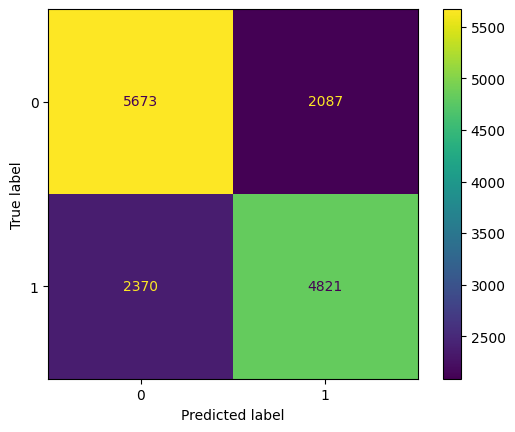

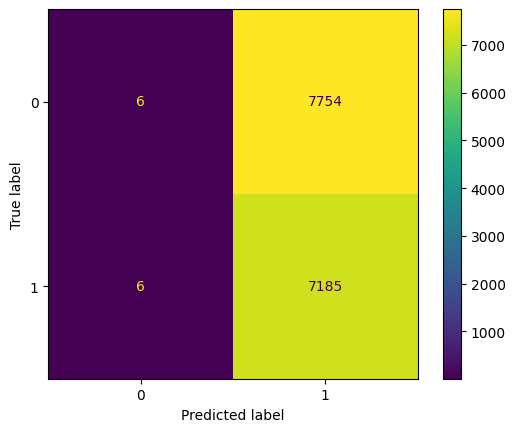

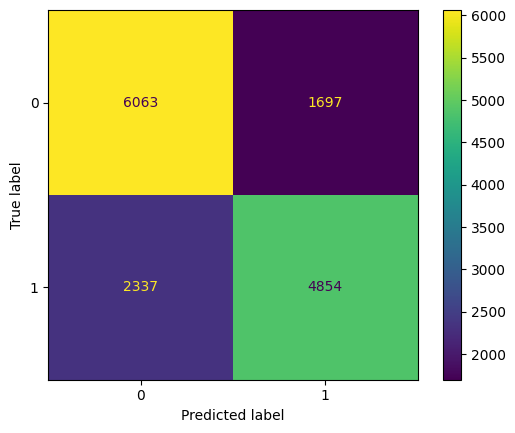

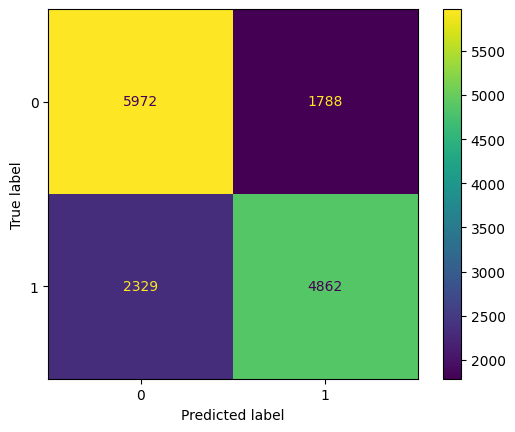

In [ ]:
for name, model in models.items():
  y_true = y_test
  y_pred = model.predict(X_test)
  y_proba = model.predict_proba(X_test)[:, 1]

  accuracy = accuracy_score(y_true, y_pred)
  precision = precision_score(y_true, y_pred, average='weighted')
  recall = recall_score(y_true, y_pred, average='weighted')
  f1 = f1_score(y_true, y_pred, average='weighted')
  # roc_auc = roc_auc_score(y_true, y_proba, average='weighted', multi_class='ovo')

  print(f"{name} Accuracy:  {accuracy:.2f}")
  print(f"{name} Precision: {precision:.2f}")
  print(f"{name} Recall:    {recall:.2f}")
  print(f"{name} F1 Score:  {f1:.2f}")
  # print(f"AUC-ROC:   {roc_auc:.2f}")

  # Confusion matrix
  cm = confusion_matrix(y_true, y_pred)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm)
  disp.plot()
  # plt.show()


In [ ]:
import joblib, json

# pick best by F1-score (same ranking you use)
best_name = results_df.sort_values("F1-score", ascending=False).index[0]
best_pipe = results[best_name]["pipeline"]

joblib.dump(best_pipe, "heart_attack_pipeline.pkl")

with open("feature_names.json", "w") as f:
    json.dump(list(X_train.columns), f)

print("Saved:", best_name)

Saved: Random Forest


In [ ]:
import pandas as pd
from sklearn.inspection import permutation_importance

feature_names = list(X_train.columns)
model = best_pipe.named_steps["model"]

# (a) RandomForest built-in importance (if available)
if hasattr(model, "feature_importances_"):
    fi = pd.DataFrame({
        "feature": feature_names,
        "importance": model.feature_importances_
    }).sort_values("importance", ascending=False)
    fi.to_csv("global_feature_importance.csv", index=False)

# (b) Permutation importance (model-agnostic)
perm = permutation_importance(
    best_pipe, X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring="roc_auc"
)

perm_df = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

perm_df.to_csv("global_permutation_importance.csv", index=False)

print("Saved global XAI: global_feature_importance.csv / global_permutation_importance.csv")

Saved global XAI: global_feature_importance.csv / global_permutation_importance.csv
